# ER-Graph 三算法验证 Notebook

这个 Notebook 用于验证 `cd_A` / `cd_B` / `cd_BOmega` 在自动生成 ER 图上的表现，覆盖：

1. 环境与依赖检查
2. 加载待验证对象与测试数据
3. 定义验证规则与评估指标
4. 执行验证流程（批量）
5. 基线对比与回归检查
6. 误差分析与可视化
7. 失败样本定位与日志导出
8. 生成可复用验证报告

In [1]:
# 1) 环境与依赖检查
import os
import sys
import json
import platform
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print('Python :', sys.version.split()[0])
print('Platform:', platform.platform())
print('numpy  :', np.__version__)
print('pandas :', pd.__version__)

try:
    import sklearn
    print('sklearn:', sklearn.__version__)
except Exception as e:
    print('sklearn not available:', e)

# 仓库根目录加入路径
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.append(repo_root)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

print('Repo root:', repo_root)

Python : 3.12.3
Platform: Windows-11-10.0.26200-SP0
numpy  : 1.26.4
pandas : 2.2.2
sklearn: 1.5.1
Repo root: c:\Users\super\DAG


In [2]:
# 2) 加载待验证对象与测试数据
from MEC import is_in_markov_equiv_class
from synthetic_dataset import SyntheticDataset
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0_epoch as cd_A
from coordinate_descent.cd_B import dag_coordinate_descent_B_epoch as cd_B
from coordinate_descent.cd_B_Omega import dag_coordinate_descent_BOmega_epoch as cd_BOmega

# 可选：GOLEM-EV / GOLEM-NV
GOLEM_IMPORT_ERROR = None
try:
    golem_src = os.path.join(repo_root, 'golemMain', 'src')
    if golem_src not in sys.path:
        sys.path.append(golem_src)
    from golem import golem as golem_fit
    HAS_GOLEM = True
except Exception as _e:
    HAS_GOLEM = False
    GOLEM_IMPORT_ERROR = _e
    print('GOLEM unavailable, will skip GOLEM-EV/NV:', _e)

# 可选：GES（causal-learn）
GES_IMPORT_ERROR = None
try:
    from causallearn.search.ScoreBased.GES import ges as ges_fit
    HAS_GES = True
except Exception as _e:
    HAS_GES = False
    GES_IMPORT_ERROR = _e
    print('GES unavailable, will skip GES:', _e)

# 配置参数（可改）
CFG = {
    'trials': 100,
    'seed': 42,
    'n': 10000,
    'd': 10,
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 5.0,
    'threshold': 0.05,
    'k': None,
    'dag_tol': 1e-8,
    'epochs_a': 500,
    'epochs_b': 500,
    'epochs_bomega': 500,
    'lambda_l0_list': [0.0, 0.1, 0.2],
    'tol': 1e-4,
    'patience': 50,
    'min_epochs': 100,
    'eps_omega': 1e-8,

    # GOLEM 参数（用于对比）
    'run_golem': True,
    'golem_num_iter': 20000,
    'golem_learning_rate': 1e-3,
    'golem_lambda1_ev': 2e-2,
    'golem_lambda1_nv': 2e-3,
    'golem_lambda2': 5.0,

    # SP / GES 参数（用于对比）
    'run_sp': True,
    'run_ges': True,
}

out_dir = os.path.join(repo_root, 'experiments', 'results')
os.makedirs(out_dir, exist_ok=True)
print('Output dir:', out_dir)
print('HAS_GOLEM:', HAS_GOLEM)
print('HAS_GES  :', HAS_GES)
CFG

c:\Users\super\DAG\experiments

Output dir: c:\Users\super\DAG\experiments\results
HAS_GOLEM: True
HAS_GES  : True


{'trials': 100,
 'seed': 42,
 'n': 10000,
 'd': 10,
 'degree': 2.0,
 'noise_type': 'gaussian_nv',
 'b_scale': 5.0,
 'threshold': 0.05,
 'k': None,
 'dag_tol': 1e-08,
 'epochs_a': 500,
 'epochs_b': 500,
 'epochs_bomega': 500,
 'lambda_l0_list': [0.0, 0.1, 0.2],
 'tol': 0.0001,
 'patience': 50,
 'min_epochs': 100,
 'eps_omega': 1e-08,
 'run_golem': True,
 'golem_num_iter': 20000,
 'golem_learning_rate': 0.001,
 'golem_lambda1_ev': 0.02,
 'golem_lambda1_nv': 0.002,
 'golem_lambda2': 5.0,
 'run_sp': True,
 'run_ges': True}

In [ ]:
# 3) 定义验证规则与评估指标

# 可选：CPDAG-SHD（优先使用 cdt.metrics.SHD_CPDAG，需要 pcalg/R）
try:
    if os.path.join(repo_root, 'toolbox') not in sys.path:
        sys.path.append(os.path.join(repo_root, 'toolbox'))
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
except Exception as _e:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False
    print('CPDAG-SHD backend unavailable, cpdag_shd will be NaN:', _e)


def weight_to_binary_adj(W: np.ndarray, threshold: float) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray):
    if not HAS_CPDAG_SHD:
        return np.nan
    try:
        val = _SHD_CPDAG(G_true.astype(int), G_est.astype(int))
        return float(val)
    except Exception:
        return np.nan


def evaluate_algorithm(G_true: np.ndarray, G_est: np.ndarray):
    return {
        'mec_match': int(is_in_markov_equiv_class(G_true, G_est)),
        'exact_match': int(np.array_equal(G_true, G_est)),
        'cpdag_shd': cpdag_shd_score(G_true, G_est),
        'n_edges_true': int(np.sum(G_true)),
        'n_edges_est': int(np.sum(G_est)),
    }


# ---------- SP helper ----------
def sp_estimate_W(X: np.ndarray):
    from itertools import permutations
    from numpy.linalg import inv, cholesky, LinAlgError

    n, p = X.shape
    if p > 8:
        raise ValueError(f'SP exhaustive search is too expensive for d={p}; please use d<=8.')

    Sigma_hat = np.cov(X, rowvar=False)

    def l0_norm(U, threshold=0.05):
        return int(np.sum(np.abs(U) > threshold))

    best_score = np.inf
    best_W, best_P = None, None

    for perm in permutations(range(p)):
        P = np.eye(p)[list(perm)]
        Sigma_perm = P @ Sigma_hat @ P.T
        try:
            Theta = inv(Sigma_perm)
            L = cholesky(Theta)
            diag_L = np.diag(L)
            sqrt_Omega = np.diag(1.0 / diag_L)
            W = np.eye(p) - L @ sqrt_Omega
            score = l0_norm(W)
            if score < best_score:
                best_score = score
                best_W = W
                best_P = P
        except LinAlgError:
            continue

    if best_W is None:
        raise RuntimeError('SP failed to find a valid structure.')

    W_est = best_P.T @ best_W @ best_P
    np.fill_diagonal(W_est, 0.0)
    return W_est


# ---------- GES helper ----------
def ges_graph_to_adj(g: np.ndarray) -> np.ndarray:
    g = np.asarray(g)
    d = g.shape[0]
    A = np.zeros((d, d), dtype=int)

    for i in range(d):
        for j in range(i + 1, d):
            a, b = g[i, j], g[j, i]
            if a == -1 and b == 1:
                A[i, j] = 1
            elif a == 1 and b == -1:
                A[j, i] = 1
            elif a == -1 and b == -1:
                A[i, j] = 1
                A[j, i] = 1
            elif a != 0 or b != 0:
                A[i, j] = int(a != 0)
                A[j, i] = int(b != 0)

    np.fill_diagonal(A, 0)
    return A

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


: 

In [ ]:
# 4) 执行验证流程（批量）
from time import perf_counter

rng = np.random.default_rng(CFG['seed'])
seeds = rng.integers(0, 10**9, size=CFG['trials'])

rows = []
detail_logs = []

for t_idx, seed in enumerate(seeds, start=1):
    dataset = SyntheticDataset(
        n=CFG['n'],
        d=CFG['d'],
        graph_type='ER',
        degree=CFG['degree'],
        noise_type=CFG['noise_type'],
        B_scale=CFG['b_scale'],
        seed=int(seed),
    )

    X = dataset.X
    S = X.T @ X / X.shape[0]

    B_true = dataset.B.copy()
    G_true = weight_to_binary_adj(B_true, threshold=0.0)

    noise_meta = np.asarray(dataset.N)
    if noise_meta.ndim == 0:
        sigma_true_diag = np.full(CFG['d'], float(noise_meta) ** 2)
    elif noise_meta.ndim == 1:
        if noise_meta.size == CFG['d']:
            sigma_true_diag = np.square(noise_meta.astype(float))
        else:
            sigma_true_diag = np.full(CFG['d'], float(np.mean(noise_meta)) ** 2)
    else:
        sigma_true_diag = np.var(noise_meta, axis=0, ddof=1)

    sigma_true_diag = np.maximum(sigma_true_diag, 1e-12)
    Omega_true_var = np.diag(sigma_true_diag)
    Omega_true_prec = np.diag(1.0 / sigma_true_diag)

    # ---------- CD family with lambda_l0 grid ----------
    for lam in CFG['lambda_l0_list']:
        lam_tag = str(lam)

        # cd_A
        t0 = perf_counter()
        A_est, G_A, obj_A, hist_A = cd_A(
            S=S,
            n_epochs=CFG['epochs_a'],
            seed=int(seed),
            threshold=CFG['threshold'],
            lambda_l0=lam,
            tol=CFG['tol'],
            patience=CFG['patience'],
            min_epochs=CFG['min_epochs'],
            verbose=False,
        )
        t1 = perf_counter()
        m_A = evaluate_algorithm(G_true, G_A)
        m_A.update({
            'trial': t_idx, 'seed': int(seed),
            'algorithm': f'cd_A_l0_{lam_tag}',
            'objective': float(obj_A), 'runtime_sec': t1 - t0,
            'epochs_used': len(hist_A),
        })
        rows.append(m_A)

        detail_logs.append({
            'trial': t_idx, 'seed': int(seed),
            'algorithm': f'cd_A_l0_{lam_tag}',
            'objective': float(obj_A),
            'mec_match': m_A['mec_match'], 'exact_match': m_A['exact_match'],
            'cpdag_shd': m_A['cpdag_shd'],
            'B_true': B_true.copy(), 'G_true': G_true.copy(),
            'Omega_true_var': Omega_true_var.copy(), 'Omega_true_prec': Omega_true_prec.copy(),
            'B_est': A_est.copy(), 'G_est': G_A.copy(), 'history': hist_A.copy(),
        })

        # cd_B
        t0 = perf_counter()
        B_est, G_B, obj_B, hist_B, _ = cd_B(
            S=S,
            n_epochs=CFG['epochs_b'],
            seed=int(seed),
            threshold=CFG['threshold'],
            lambda_l0=lam,
            k=CFG['k'],
            dag_tol=CFG['dag_tol'],
            tol=CFG['tol'],
            patience=CFG['patience'],
            min_epochs=CFG['min_epochs'],
            verbose=False,
        )
        t1 = perf_counter()
        m_B = evaluate_algorithm(G_true, G_B)
        m_B.update({
            'trial': t_idx, 'seed': int(seed),
            'algorithm': f'cd_B_l0_{lam_tag}',
            'objective': float(obj_B), 'runtime_sec': t1 - t0,
            'epochs_used': len(hist_B),
        })
        rows.append(m_B)

        detail_logs.append({
            'trial': t_idx, 'seed': int(seed),
            'algorithm': f'cd_B_l0_{lam_tag}',
            'objective': float(obj_B),
            'mec_match': m_B['mec_match'], 'exact_match': m_B['exact_match'],
            'cpdag_shd': m_B['cpdag_shd'],
            'B_true': B_true.copy(), 'G_true': G_true.copy(),
            'Omega_true_var': Omega_true_var.copy(), 'Omega_true_prec': Omega_true_prec.copy(),
            'B_est': B_est.copy(), 'G_est': G_B.copy(), 'history': hist_B.copy(),
        })

        # cd_BOmega
        t0 = perf_counter()
        B_om_est, G_BOm, obj_BOm, hist_BOm, _ = cd_BOmega(
            S=S,
            Omega=np.eye(CFG['d']),
            n_epochs=CFG['epochs_bomega'],
            seed=int(seed),
            threshold=CFG['threshold'],
            lambda_l0=lam,
            k=CFG['k'],
            dag_tol=CFG['dag_tol'],
            tol=CFG['tol'],
            patience=CFG['patience'],
            min_epochs=CFG['min_epochs'],
            eps_omega=CFG['eps_omega'],
            verbose=False,
        )
        t1 = perf_counter()
        m_BOm = evaluate_algorithm(G_true, G_BOm)
        m_BOm.update({
            'trial': t_idx, 'seed': int(seed),
            'algorithm': f'cd_BOmega_l0_{lam_tag}',
            'objective': float(obj_BOm), 'runtime_sec': t1 - t0,
            'epochs_used': len(hist_BOm),
        })
        rows.append(m_BOm)

        detail_logs.append({
            'trial': t_idx, 'seed': int(seed),
            'algorithm': f'cd_BOmega_l0_{lam_tag}',
            'objective': float(obj_BOm),
            'mec_match': m_BOm['mec_match'], 'exact_match': m_BOm['exact_match'],
            'cpdag_shd': m_BOm['cpdag_shd'],
            'B_true': B_true.copy(), 'G_true': G_true.copy(),
            'Omega_true_var': Omega_true_var.copy(), 'Omega_true_prec': Omega_true_prec.copy(),
            'B_est': B_om_est.copy(), 'G_est': G_BOm.copy(), 'history': hist_BOm.copy(),
        })

    # ---------- GOLEM-EV / GOLEM-NV ----------
    if CFG.get('run_golem', True) and HAS_GOLEM:
        try:
            t0 = perf_counter()
            B_golem_ev = golem_fit(
                X,
                lambda_1=CFG['golem_lambda1_ev'],
                lambda_2=CFG['golem_lambda2'],
                equal_variances=True,
                num_iter=CFG['golem_num_iter'],
                learning_rate=CFG['golem_learning_rate'],
                seed=int(seed),
            )
            t1 = perf_counter()
            G_golem_ev = weight_to_binary_adj(B_golem_ev, threshold=CFG['threshold'])
            m_golem_ev = evaluate_algorithm(G_true, G_golem_ev)
            m_golem_ev.update({'trial': t_idx, 'seed': int(seed), 'algorithm': 'golem_ev', 'objective': np.nan, 'runtime_sec': t1 - t0, 'epochs_used': np.nan})
            rows.append(m_golem_ev)

            detail_logs.append({
                'trial': t_idx, 'seed': int(seed), 'algorithm': 'golem_ev',
                'objective': np.nan,
                'mec_match': m_golem_ev['mec_match'], 'exact_match': m_golem_ev['exact_match'],
                'cpdag_shd': m_golem_ev['cpdag_shd'],
                'B_true': B_true.copy(), 'G_true': G_true.copy(),
                'Omega_true_var': Omega_true_var.copy(), 'Omega_true_prec': Omega_true_prec.copy(),
                'B_est': B_golem_ev.copy(), 'G_est': G_golem_ev.copy(), 'history': [],
            })

            t0 = perf_counter()
            B_golem_nv = golem_fit(
                X,
                lambda_1=CFG['golem_lambda1_nv'],
                lambda_2=CFG['golem_lambda2'],
                equal_variances=False,
                num_iter=CFG['golem_num_iter'],
                learning_rate=CFG['golem_learning_rate'],
                seed=int(seed),
            )
            t1 = perf_counter()
            G_golem_nv = weight_to_binary_adj(B_golem_nv, threshold=CFG['threshold'])
            m_golem_nv = evaluate_algorithm(G_true, G_golem_nv)
            m_golem_nv.update({'trial': t_idx, 'seed': int(seed), 'algorithm': 'golem_nv', 'objective': np.nan, 'runtime_sec': t1 - t0, 'epochs_used': np.nan})
            rows.append(m_golem_nv)

            detail_logs.append({
                'trial': t_idx, 'seed': int(seed), 'algorithm': 'golem_nv',
                'objective': np.nan,
                'mec_match': m_golem_nv['mec_match'], 'exact_match': m_golem_nv['exact_match'],
                'cpdag_shd': m_golem_nv['cpdag_shd'],
                'B_true': B_true.copy(), 'G_true': G_true.copy(),
                'Omega_true_var': Omega_true_var.copy(), 'Omega_true_prec': Omega_true_prec.copy(),
                'B_est': B_golem_nv.copy(), 'G_est': G_golem_nv.copy(), 'history': [],
            })
        except Exception as e:
            print(f"[Trial {t_idx:03d}] GOLEM failed, skip this trial for GOLEM: {e}")

    # ---------- SP ----------
    if CFG.get('run_sp', True):
        try:
            t0 = perf_counter()
            B_sp = sp_estimate_W(X)
            t1 = perf_counter()
            G_sp = weight_to_binary_adj(B_sp, threshold=CFG['threshold'])
            m_sp = evaluate_algorithm(G_true, G_sp)
            m_sp.update({'trial': t_idx, 'seed': int(seed), 'algorithm': 'sp', 'objective': np.nan, 'runtime_sec': t1 - t0, 'epochs_used': np.nan})
            rows.append(m_sp)

            detail_logs.append({
                'trial': t_idx, 'seed': int(seed), 'algorithm': 'sp',
                'objective': np.nan,
                'mec_match': m_sp['mec_match'], 'exact_match': m_sp['exact_match'],
                'cpdag_shd': m_sp['cpdag_shd'],
                'B_true': B_true.copy(), 'G_true': G_true.copy(),
                'Omega_true_var': Omega_true_var.copy(), 'Omega_true_prec': Omega_true_prec.copy(),
                'B_est': B_sp.copy(), 'G_est': G_sp.copy(), 'history': [],
            })
        except Exception as e:
            print(f"[Trial {t_idx:03d}] SP failed, skip this trial for SP: {e}")

    # ---------- GES ----------
    if CFG.get('run_ges', True) and HAS_GES:
        try:
            t0 = perf_counter()
            ges_rec = ges_fit(X)
            t1 = perf_counter()
            G_ges = ges_graph_to_adj(ges_rec['G'].graph)
            m_ges = evaluate_algorithm(G_true, G_ges)
            m_ges.update({'trial': t_idx, 'seed': int(seed), 'algorithm': 'ges', 'objective': np.nan, 'runtime_sec': t1 - t0, 'epochs_used': np.nan})
            rows.append(m_ges)

            detail_logs.append({
                'trial': t_idx, 'seed': int(seed), 'algorithm': 'ges',
                'objective': np.nan,
                'mec_match': m_ges['mec_match'], 'exact_match': m_ges['exact_match'],
                'cpdag_shd': m_ges['cpdag_shd'],
                'B_true': B_true.copy(), 'G_true': G_true.copy(),
                'Omega_true_var': Omega_true_var.copy(), 'Omega_true_prec': Omega_true_prec.copy(),
                'B_est': np.asarray(ges_rec['G'].graph).copy(), 'G_est': G_ges.copy(), 'history': [],
            })
        except Exception as e:
            print(f"[Trial {t_idx:03d}] GES failed, skip this trial for GES: {e}")

    print(f"Trial {t_idx:03d}/{CFG['trials']} done")


df_results = pd.DataFrame(rows)
df_summary = df_results.groupby('algorithm', as_index=False).agg({
    'mec_match': 'mean',
    'exact_match': 'mean',
    'cpdag_shd': ['mean', 'std'],
    'runtime_sec': ['mean'],
})

flat_cols = []
for c in df_summary.columns:
    if isinstance(c, tuple):
        a, b = c
        flat_cols.append(a if b == '' else f"{a}_{b}")
    else:
        flat_cols.append(c)
df_summary.columns = flat_cols

print('Results shape:', df_results.shape)
print('Detail logs :', len(detail_logs))
print('HAS_CPDAG_SHD:', HAS_CPDAG_SHD)
print('HAS_GOLEM:', HAS_GOLEM)
print('HAS_GES  :', HAS_GES)
display(df_summary)


[Trial 001] SP failed, skip this trial for SP: SP exhaustive search is too expensive for d=10; please use d<=8.
Trial 001/100 done
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
[Trial 002] SP failed, skip this trial for SP: SP exhaustive search is too expensive for d=10; please use d<=8.
Trial 002/100 done
[Trial 003] SP failed, skip this trial for SP: SP exhaustive search is too expensive for d=10; please use d<=8.
Trial 003/100 done
[Trial 004] SP failed, skip this trial for SP: SP exhaustive search is too expensive for d=10; please use d<=8.
Trial 004/100 done
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
[Trial 005] SP failed, skip this trial for SP: SP exhaustive search is too expensive for d=10; pl

overflow encountered in matmul
invalid value encountered in reduce
overflow encountered in reduce



R Python Error Output 
-----------------------

C:\Users\super\AppData\Local\Temp\cdt_CPDAG_cace199f-9b11-4c4b-94af-65a3882230d3\result.csv not found.
[Trial 027] SP failed, skip this trial for SP: SP exhaustive search is too expensive for d=10; please use d<=8.
Trial 027/100 done
[Trial 028] SP failed, skip this trial for SP: SP exhaustive search is too expensive for d=10; please use d<=8.
Trial 028/100 done
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, c

In [ ]:
# 5) 基线对比与回归检查
# 如果已有历史 summary CSV，则自动对比
baseline_path = os.path.join(out_dir, 'er_cd_benchmark_summary.csv')

if os.path.exists(baseline_path):
    df_base = pd.read_csv(baseline_path)
    # 精简后仅关注：mec_rate / exact_rate / cpdag_shd_mean
    cols_keep = [c for c in ['algorithm', 'mec_rate', 'exact_rate', 'cpdag_shd_mean'] if c in df_base.columns]
    df_base = df_base[cols_keep].copy()

    df_curr = df_summary.copy()
    rename_map = {
        'mec_match_mean': 'mec_rate_curr',
        'exact_match_mean': 'exact_rate_curr',
        'cpdag_shd_mean': 'cpdag_shd_mean_curr',
    }
    for old, new in rename_map.items():
        if old in df_curr.columns:
            df_curr.rename(columns={old: new}, inplace=True)

    df_cmp = pd.merge(df_base, df_curr, on='algorithm', how='inner')

    if 'mec_rate' in df_cmp.columns and 'mec_rate_curr' in df_cmp.columns:
        df_cmp['delta_mec'] = df_cmp['mec_rate_curr'] - df_cmp['mec_rate']
    if 'exact_rate' in df_cmp.columns and 'exact_rate_curr' in df_cmp.columns:
        df_cmp['delta_exact'] = df_cmp['exact_rate_curr'] - df_cmp['exact_rate']
    if 'cpdag_shd_mean' in df_cmp.columns and 'cpdag_shd_mean_curr' in df_cmp.columns:
        df_cmp['delta_cpdag_shd'] = df_cmp['cpdag_shd_mean_curr'] - df_cmp['cpdag_shd_mean']

    # 回归告警规则：MEC 下降超过 0.05 或 CPDAG-SHD 上升超过 0.5
    regressions = pd.DataFrame()
    if 'delta_mec' in df_cmp.columns and 'delta_cpdag_shd' in df_cmp.columns:
        regressions = df_cmp[(df_cmp['delta_mec'] < -0.05) | (df_cmp['delta_cpdag_shd'] > 0.5)]

    print('Loaded baseline:', baseline_path)
    display(df_cmp)
    if len(regressions) > 0:
        print('Regression alerts:')
        display(regressions)
    else:
        print('No regression alerts.')
else:
    df_cmp = None
    regressions = None
    print('No baseline found. Skip regression check.')

No baseline found. Skip regression check.


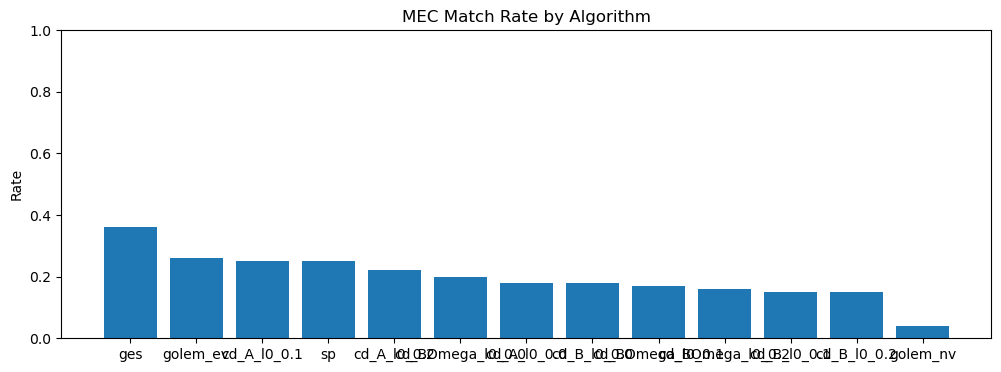

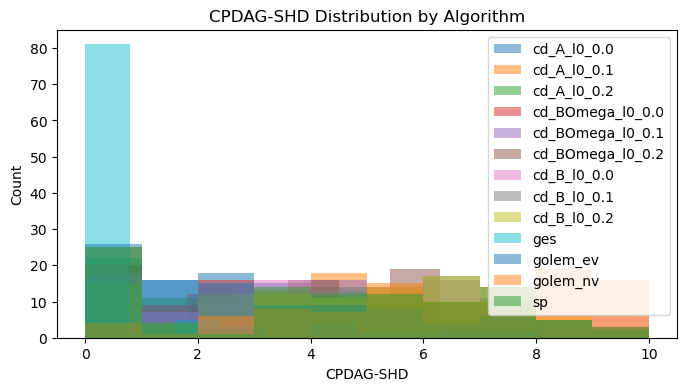

In [ ]:
# 6) 误差分析与可视化（精简版）

# 1) 各算法 MEC 命中率
mec_rates = df_results.groupby('algorithm')['mec_match'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 4))
plt.bar(mec_rates.index, mec_rates.values)
plt.title('MEC Match Rate by Algorithm')
plt.ylabel('Rate')
plt.ylim(0, 1.0)
plt.show()

# 2) 各算法 CPDAG-SHD 分布（若可用）
if 'cpdag_shd' in df_results.columns and df_results['cpdag_shd'].notna().any():
    plt.figure(figsize=(8, 4))
    for alg in sorted(df_results['algorithm'].unique()):
        vals = df_results.loc[(df_results['algorithm'] == alg) & (df_results['cpdag_shd'].notna()), 'cpdag_shd'].values
        if len(vals) > 0:
            plt.hist(vals, bins=min(10, max(3, len(vals))), alpha=0.5, label=alg)
    plt.title('CPDAG-SHD Distribution by Algorithm')
    plt.xlabel('CPDAG-SHD')
    plt.ylabel('Count')
    plt.legend()
    plt.show()
else:
    print('CPDAG-SHD 不可用（缺少 R/pcalg 或当前结果全为 NaN）。')

In [ ]:
# 7) 失败样本定位与日志导出
# 失败定义：mec_match == 0 或 exact_match == 0
fail_df = df_results[(df_results['mec_match'] == 0) | (df_results['exact_match'] == 0)].copy()

fail_csv = os.path.join(out_dir, 'validate_er_graph_cd_failures.csv')
fail_json = os.path.join(out_dir, 'validate_er_graph_cd_failures.json')

fail_df.to_csv(fail_csv, index=False)
with open(fail_json, 'w', encoding='utf-8') as f:
    json.dump(fail_df.to_dict(orient='records'), f, ensure_ascii=False, indent=2)

print('Failure count:', len(fail_df))
print('Saved:', fail_csv)
print('Saved:', fail_json)
display(fail_df.head(20))

# ---------- 打印失败样本的详细矩阵信息 ----------
TARGET_ALG = None      # 例如 'cd_A' / 'cd_B' / 'cd_BOmega'；None 表示不过滤
MAX_PRINT = 5          # 最多打印多少个失败样本

detail_map = {(x['trial'], x['algorithm']): x for x in detail_logs}

# 优先按 CPDAG-SHD（若可用）排序，否则按 trial
if 'cpdag_shd' in fail_df.columns:
    failed_cases = fail_df.copy()
    failed_cases['_sort_cpdag'] = failed_cases['cpdag_shd'].fillna(-1)
    failed_cases = failed_cases.sort_values(by=['_sort_cpdag', 'trial'], ascending=[False, True]).drop(columns=['_sort_cpdag'])
else:
    failed_cases = fail_df.sort_values(by=['trial'], ascending=[True]).copy()

if TARGET_ALG is not None:
    failed_cases = failed_cases[failed_cases['algorithm'] == TARGET_ALG]

failed_cases = failed_cases.head(MAX_PRINT)

if len(failed_cases) == 0:
    print('没有符合条件的失败样本可打印。')
else:
    print(f'准备打印 {len(failed_cases)} 个失败样本详细信息...')

for _, r in failed_cases.iterrows():
    key = (int(r['trial']), r['algorithm'])
    info = detail_map.get(key, None)
    if info is None:
        continue

    print('\n' + '=' * 90)
    cpdag_val = info.get('cpdag_shd', np.nan)
    cpdag_txt = 'NaN' if pd.isna(cpdag_val) else f"{cpdag_val:.3f}"
    print(f"Trial={info['trial']} | Seed={info['seed']} | Alg={info['algorithm']}")
    print(f"Objective={info['objective']:.6f} | CPDAG-SHD={cpdag_txt} | MEC={info['mec_match']} | Exact={info['exact_match']}")
    print('-' * 90)

    print('B_true:')
    print(np.array2string(info['B_true'], precision=3, suppress_small=True))

    print('\nOmega_true (variance diag matrix):')
    print(np.array2string(info['Omega_true_var'], precision=3, suppress_small=True))

    print('\nOmega_true (precision diag matrix):')
    print(np.array2string(info['Omega_true_prec'], precision=3, suppress_small=True))

    print('\nB_est:')
    print(np.array2string(info['B_est'], precision=3, suppress_small=True))

    print('\nG_true:')
    print(info['G_true'])

    print('\nG_est:')
    print(info['G_est'])

Failure count: 1100
Saved: c:\Users\super\DAG\experiments\results\validate_er_graph_cd_failures.csv
Saved: c:\Users\super\DAG\experiments\results\validate_er_graph_cd_failures.json


,mec_match,exact_match,cpdag_shd,n_edges_true,n_edges_est,trial,seed,algorithm,objective,runtime_sec,epochs_used
0,0,0,7.0,6,9,1,89250953,cd_A_l0_0.0,11.055922,5.386778,500.0
1,0,0,7.0,6,9,1,89250953,cd_B_l0_0.0,5.305479,4.367012,500.0
2,0,0,7.0,6,9,1,89250953,cd_BOmega_l0_0.0,5.163005,3.692018,449.0
3,0,0,7.0,6,9,1,89250953,cd_A_l0_0.1,11.055961,4.558356,500.0
4,0,0,7.0,6,7,1,89250953,cd_B_l0_0.1,10.193301,1.112263,149.0
5,0,0,7.0,6,7,1,89250953,cd_BOmega_l0_0.1,7.596651,1.212503,149.0
6,0,0,7.0,6,9,1,89250953,cd_A_l0_0.2,11.047975,4.545970,500.0
7,0,0,5.0,6,7,1,89250953,cd_B_l0_0.2,6.233693,1.023911,149.0
8,0,0,7.0,6,7,1,89250953,cd_BOmega_l0_0.2,7.596651,1.205289,149.0
9,0,0,3.0,6,8,1,89250953,golem_ev,NaN,28.503603,NaN


准备打印 5 个失败样本详细信息...

Trial=19 | Seed=500351915 | Alg=cd_B_l0_0.0
Objective=3.208768 | CPDAG-SHD=10.000 | MEC=0 | Exact=0
------------------------------------------------------------------------------------------
B_true:
[[ 0.    -5.767 -6.833  0.     0.   ]
 [ 0.     0.     9.493  0.     0.   ]
 [ 0.     0.     0.     0.     9.799]
 [ 0.    -8.624  7.033  0.    -8.808]
 [ 0.     0.     0.     0.     0.   ]]

Omega_true (variance diag matrix):
[[1.027 0.    0.    0.    0.   ]
 [0.    1.67  0.    0.    0.   ]
 [0.    0.    1.187 0.    0.   ]
 [0.    0.    0.    2.895 0.   ]
 [0.    0.    0.    0.    1.625]]

Omega_true (precision diag matrix):
[[0.974 0.    0.    0.    0.   ]
 [0.    0.599 0.    0.    0.   ]
 [0.    0.    0.842 0.    0.   ]
 [0.    0.    0.    0.345 0.   ]
 [0.    0.    0.    0.    0.616]]

B_est:
[[   0.      -5.762   -0.698   -0.784 -106.804]
 [   0.       0.      -0.019   -0.021   86.139]
 [   0.       0.       0.      -0.009    0.   ]
 [   0.       0.       0.       

In [ ]:
# 8) 生成可复用验证报告
now = datetime.now()
now_str = now.strftime('%Y-%m-%d %H:%M:%S')
run_id = now.strftime('%Y%m%d_%H%M%S')

# 带时间戳（不会覆盖）
report_path = os.path.join(out_dir, f'validate_er_graph_cd_report_{run_id}.md')
summary_csv = os.path.join(out_dir, f'validate_er_graph_cd_summary_{run_id}.csv')
trial_csv = os.path.join(out_dir, f'validate_er_graph_cd_trials_{run_id}.csv')

# latest（会覆盖，便于固定路径读取）
report_path_latest = os.path.join(out_dir, 'validate_er_graph_cd_report.md')
summary_csv_latest = os.path.join(out_dir, 'validate_er_graph_cd_summary.csv')
trial_csv_latest = os.path.join(out_dir, 'validate_er_graph_cd_trials.csv')

df_summary.to_csv(summary_csv, index=False)
df_results.to_csv(trial_csv, index=False)

df_summary.to_csv(summary_csv_latest, index=False)
df_results.to_csv(trial_csv_latest, index=False)

lines = []
lines.append('# ER-Graph Validation Report\n')
lines.append(f'- Generated at: {now_str}')
lines.append(f'- Run ID: {run_id}')
lines.append(f"- Trials: {CFG['trials']}, n={CFG['n']}, d={CFG['d']}, degree={CFG['degree']}")
lambda_cfg = CFG.get('lambda_l0_list', CFG.get('lambda_l0', 'N/A'))
lines.append(f"- Noise: {CFG['noise_type']}, threshold={CFG['threshold']}, lambda_l0_list={lambda_cfg}\n")

lines.append('## Summary (mean metrics)\n')
lines.append(df_summary.to_markdown(index=False))
lines.append('\n\n## Failure stats\n')
lines.append(f'- Failure count: {len(fail_df)}')
lines.append(f'- Failure CSV: {fail_csv}')
lines.append(f'- Failure JSON: {fail_json}')

if 'regressions' in globals() and regressions is not None and len(regressions) > 0:
    lines.append('\n\n## Regression alerts\n')
    lines.append(regressions.to_markdown(index=False))

report_content = '\n'.join(lines)

with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_content)

with open(report_path_latest, 'w', encoding='utf-8') as f:
    f.write(report_content)

print('Saved trial CSV (run):', trial_csv)
print('Saved summary CSV (run):', summary_csv)
print('Saved report (run):', report_path)
print('Saved trial CSV (latest):', trial_csv_latest)
print('Saved summary CSV (latest):', summary_csv_latest)
print('Saved report (latest):', report_path_latest)

report_path

Saved trial CSV (run): c:\Users\super\DAG\experiments\results\validate_er_graph_cd_trials_20260218_222211.csv
Saved summary CSV (run): c:\Users\super\DAG\experiments\results\validate_er_graph_cd_summary_20260218_222211.csv
Saved report (run): c:\Users\super\DAG\experiments\results\validate_er_graph_cd_report_20260218_222211.md
Saved trial CSV (latest): c:\Users\super\DAG\experiments\results\validate_er_graph_cd_trials.csv
Saved summary CSV (latest): c:\Users\super\DAG\experiments\results\validate_er_graph_cd_summary.csv
Saved report (latest): c:\Users\super\DAG\experiments\results\validate_er_graph_cd_report.md


'c:\\Users\\super\\DAG\\experiments\\results\\validate_er_graph_cd_report_20260218_222211.md'

## 9) 多 d（5/10/15/20）算法时间与精度调查

本节独立于上面流程，按 d 分层比较算法：
- 指标：`mec_match_mean`、`cpdag_shd_mean`、`runtime_sec_mean`
- 额外（仅 GOLEM 和 CD 家族）：记录 score 变化（起点、终点、delta、相对变化）并可视化

In [ ]:
# 10) 运行多 d 调查（含 GOLEM/CD score 变化）
from golem import golem as _golem_fit_ref
from models import GolemModel
from trainers import GolemTrainer

CFG_D = {
    'd_list': [5, 10, 15, 20],
    'trials_per_d': 10,
    'seed': 123,
    'n': 5000,
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 5.0,
    'threshold': 0.05,

    # CD family
    'lambda_l0': 0.0,
    'epochs_a': 500,
    'epochs_b': 500,
    'epochs_bomega': 500,
    'tol': 1e-4,
    'patience': 50,
    'min_epochs': 100,
    'k': None,
    'dag_tol': 1e-8,
    'eps_omega': 1e-8,

    # GOLEM
    'run_golem_ev': True,
    'run_golem_nv': True,
    'golem_num_iter': 5000,
    'golem_learning_rate': 1e-3,
    'golem_lambda1_ev': 2e-2,
    'golem_lambda1_nv': 2e-3,
    'golem_lambda2': 5.0,
    'golem_record_every': 100,

    # SP / GES
    'run_sp': True,
    'run_ges': True,
    'sp_max_d': 8,
}


def run_golem_with_score_history(
    X: np.ndarray,
    lambda_1: float,
    lambda_2: float,
    equal_variances: bool,
    num_iter: int,
    learning_rate: float,
    seed: int,
    record_every: int = 100,
):
    Xc = X - X.mean(axis=0, keepdims=True)
    n, d = Xc.shape

    model = GolemModel(
        n=n,
        d=d,
        lambda_1=lambda_1,
        lambda_2=lambda_2,
        equal_variances=equal_variances,
        seed=seed,
        B_init=None,
    )
    trainer = GolemTrainer(learning_rate=learning_rate)
    model.sess.run(__import__('tensorflow').compat.v1.global_variables_initializer())

    score_history = []
    B_est = None
    for i in range(0, int(num_iter) + 1):
        if i == 0:
            score, likelihood, h, B_est = trainer.eval_iter(model, Xc)
        else:
            score, likelihood, h, B_est = trainer.train_iter(model, Xc)

        if (i % record_every == 0) or (i == int(num_iter)):
            score_history.append(float(score))

    model.sess.close()
    return np.asarray(B_est), score_history


rng = np.random.default_rng(CFG_D['seed'])
rows_d = []
score_logs = []

for d in CFG_D['d_list']:
    seeds_d = rng.integers(0, 10**9, size=CFG_D['trials_per_d'])
    print(f"\n[d={d}] trials={CFG_D['trials_per_d']}")

    for t_idx, seed in enumerate(seeds_d, start=1):
        dataset = SyntheticDataset(
            n=CFG_D['n'],
            d=d,
            graph_type='ER',
            degree=CFG_D['degree'],
            noise_type=CFG_D['noise_type'],
            B_scale=CFG_D['b_scale'],
            seed=int(seed),
        )

        X = dataset.X
        S = X.T @ X / X.shape[0]
        G_true = weight_to_binary_adj(dataset.B.copy(), threshold=0.0)

        # ----- cd_A -----
        t0 = perf_counter()
        A_est, G_A, obj_A, hist_A = cd_A(
            S=S,
            n_epochs=CFG_D['epochs_a'],
            seed=int(seed),
            threshold=CFG_D['threshold'],
            lambda_l0=CFG_D['lambda_l0'],
            tol=CFG_D['tol'],
            patience=CFG_D['patience'],
            min_epochs=CFG_D['min_epochs'],
            verbose=False,
        )
        t1 = perf_counter()
        m_A = evaluate_algorithm(G_true, G_A)
        score_hist_A = list(hist_A) if len(hist_A) > 0 else [float(obj_A)]
        rows_d.append({
            'd': d,
            'trial': t_idx,
            'seed': int(seed),
            'algorithm': 'cd_A',
            'mec_match': m_A['mec_match'],
            'cpdag_shd': m_A['cpdag_shd'],
            'runtime_sec': float(t1 - t0),
            'score_start': float(score_hist_A[0]),
            'score_end': float(score_hist_A[-1]),
            'score_delta': float(score_hist_A[-1] - score_hist_A[0]),
            'score_rel_change': float((score_hist_A[-1] - score_hist_A[0]) / (abs(score_hist_A[0]) + 1e-12)),
        })
        score_logs.append({'d': d, 'trial': t_idx, 'algorithm': 'cd_A', 'score_history': score_hist_A})

        # ----- cd_B -----
        t0 = perf_counter()
        B_est, G_B, obj_B, hist_B, _ = cd_B(
            S=S,
            n_epochs=CFG_D['epochs_b'],
            seed=int(seed),
            threshold=CFG_D['threshold'],
            lambda_l0=CFG_D['lambda_l0'],
            k=CFG_D['k'],
            dag_tol=CFG_D['dag_tol'],
            tol=CFG_D['tol'],
            patience=CFG_D['patience'],
            min_epochs=CFG_D['min_epochs'],
            verbose=False,
        )
        t1 = perf_counter()
        m_B = evaluate_algorithm(G_true, G_B)
        score_hist_B = list(hist_B) if len(hist_B) > 0 else [float(obj_B)]
        rows_d.append({
            'd': d,
            'trial': t_idx,
            'seed': int(seed),
            'algorithm': 'cd_B',
            'mec_match': m_B['mec_match'],
            'cpdag_shd': m_B['cpdag_shd'],
            'runtime_sec': float(t1 - t0),
            'score_start': float(score_hist_B[0]),
            'score_end': float(score_hist_B[-1]),
            'score_delta': float(score_hist_B[-1] - score_hist_B[0]),
            'score_rel_change': float((score_hist_B[-1] - score_hist_B[0]) / (abs(score_hist_B[0]) + 1e-12)),
        })
        score_logs.append({'d': d, 'trial': t_idx, 'algorithm': 'cd_B', 'score_history': score_hist_B})

        # ----- cd_BOmega -----
        t0 = perf_counter()
        B_om_est, G_BOm, obj_BOm, hist_BOm, _ = cd_BOmega(
            S=S,
            Omega=np.eye(d),
            n_epochs=CFG_D['epochs_bomega'],
            seed=int(seed),
            threshold=CFG_D['threshold'],
            lambda_l0=CFG_D['lambda_l0'],
            k=CFG_D['k'],
            dag_tol=CFG_D['dag_tol'],
            tol=CFG_D['tol'],
            patience=CFG_D['patience'],
            min_epochs=CFG_D['min_epochs'],
            eps_omega=CFG_D['eps_omega'],
            verbose=False,
        )
        t1 = perf_counter()
        m_BOm = evaluate_algorithm(G_true, G_BOm)
        score_hist_BOm = list(hist_BOm) if len(hist_BOm) > 0 else [float(obj_BOm)]
        rows_d.append({
            'd': d,
            'trial': t_idx,
            'seed': int(seed),
            'algorithm': 'cd_BOmega',
            'mec_match': m_BOm['mec_match'],
            'cpdag_shd': m_BOm['cpdag_shd'],
            'runtime_sec': float(t1 - t0),
            'score_start': float(score_hist_BOm[0]),
            'score_end': float(score_hist_BOm[-1]),
            'score_delta': float(score_hist_BOm[-1] - score_hist_BOm[0]),
            'score_rel_change': float((score_hist_BOm[-1] - score_hist_BOm[0]) / (abs(score_hist_BOm[0]) + 1e-12)),
        })
        score_logs.append({'d': d, 'trial': t_idx, 'algorithm': 'cd_BOmega', 'score_history': score_hist_BOm})

        # ----- GOLEM-EV -----
        if CFG_D['run_golem_ev'] and HAS_GOLEM:
            try:
                t0 = perf_counter()
                B_golem_ev, hist_golem_ev = run_golem_with_score_history(
                    X=X,
                    lambda_1=CFG_D['golem_lambda1_ev'],
                    lambda_2=CFG_D['golem_lambda2'],
                    equal_variances=True,
                    num_iter=CFG_D['golem_num_iter'],
                    learning_rate=CFG_D['golem_learning_rate'],
                    seed=int(seed),
                    record_every=CFG_D['golem_record_every'],
                )
                t1 = perf_counter()
                G_golem_ev = weight_to_binary_adj(B_golem_ev, threshold=CFG_D['threshold'])
                m_golem_ev = evaluate_algorithm(G_true, G_golem_ev)
                rows_d.append({
                    'd': d,
                    'trial': t_idx,
                    'seed': int(seed),
                    'algorithm': 'golem_ev',
                    'mec_match': m_golem_ev['mec_match'],
                    'cpdag_shd': m_golem_ev['cpdag_shd'],
                    'runtime_sec': float(t1 - t0),
                    'score_start': float(hist_golem_ev[0]) if len(hist_golem_ev) > 0 else np.nan,
                    'score_end': float(hist_golem_ev[-1]) if len(hist_golem_ev) > 0 else np.nan,
                    'score_delta': float(hist_golem_ev[-1] - hist_golem_ev[0]) if len(hist_golem_ev) > 0 else np.nan,
                    'score_rel_change': float((hist_golem_ev[-1] - hist_golem_ev[0]) / (abs(hist_golem_ev[0]) + 1e-12)) if len(hist_golem_ev) > 0 else np.nan,
                })
                score_logs.append({'d': d, 'trial': t_idx, 'algorithm': 'golem_ev', 'score_history': hist_golem_ev})
            except Exception as e:
                print(f"[d={d} trial={t_idx}] GOLEM-EV failed: {e}")

        # ----- GOLEM-NV -----
        if CFG_D['run_golem_nv'] and HAS_GOLEM:
            try:
                t0 = perf_counter()
                B_golem_nv, hist_golem_nv = run_golem_with_score_history(
                    X=X,
                    lambda_1=CFG_D['golem_lambda1_nv'],
                    lambda_2=CFG_D['golem_lambda2'],
                    equal_variances=False,
                    num_iter=CFG_D['golem_num_iter'],
                    learning_rate=CFG_D['golem_learning_rate'],
                    seed=int(seed),
                    record_every=CFG_D['golem_record_every'],
                )
                t1 = perf_counter()
                G_golem_nv = weight_to_binary_adj(B_golem_nv, threshold=CFG_D['threshold'])
                m_golem_nv = evaluate_algorithm(G_true, G_golem_nv)
                rows_d.append({
                    'd': d,
                    'trial': t_idx,
                    'seed': int(seed),
                    'algorithm': 'golem_nv',
                    'mec_match': m_golem_nv['mec_match'],
                    'cpdag_shd': m_golem_nv['cpdag_shd'],
                    'runtime_sec': float(t1 - t0),
                    'score_start': float(hist_golem_nv[0]) if len(hist_golem_nv) > 0 else np.nan,
                    'score_end': float(hist_golem_nv[-1]) if len(hist_golem_nv) > 0 else np.nan,
                    'score_delta': float(hist_golem_nv[-1] - hist_golem_nv[0]) if len(hist_golem_nv) > 0 else np.nan,
                    'score_rel_change': float((hist_golem_nv[-1] - hist_golem_nv[0]) / (abs(hist_golem_nv[0]) + 1e-12)) if len(hist_golem_nv) > 0 else np.nan,
                })
                score_logs.append({'d': d, 'trial': t_idx, 'algorithm': 'golem_nv', 'score_history': hist_golem_nv})
            except Exception as e:
                print(f"[d={d} trial={t_idx}] GOLEM-NV failed: {e}")

        # ----- SP -----
        if CFG_D['run_sp']:
            try:
                if d > CFG_D['sp_max_d']:
                    raise ValueError(f'SP skipped for d={d} > sp_max_d={CFG_D["sp_max_d"]}')
                t0 = perf_counter()
                B_sp = sp_estimate_W(X)
                t1 = perf_counter()
                G_sp = weight_to_binary_adj(B_sp, threshold=CFG_D['threshold'])
                m_sp = evaluate_algorithm(G_true, G_sp)
                rows_d.append({
                    'd': d,
                    'trial': t_idx,
                    'seed': int(seed),
                    'algorithm': 'sp',
                    'mec_match': m_sp['mec_match'],
                    'cpdag_shd': m_sp['cpdag_shd'],
                    'runtime_sec': float(t1 - t0),
                    'score_start': np.nan,
                    'score_end': np.nan,
                    'score_delta': np.nan,
                    'score_rel_change': np.nan,
                })
            except Exception as e:
                print(f"[d={d} trial={t_idx}] SP skipped/failed: {e}")

        # ----- GES -----
        if CFG_D['run_ges'] and HAS_GES:
            try:
                t0 = perf_counter()
                ges_rec = ges_fit(X)
                t1 = perf_counter()
                G_ges = ges_graph_to_adj(ges_rec['G'].graph)
                m_ges = evaluate_algorithm(G_true, G_ges)
                rows_d.append({
                    'd': d,
                    'trial': t_idx,
                    'seed': int(seed),
                    'algorithm': 'ges',
                    'mec_match': m_ges['mec_match'],
                    'cpdag_shd': m_ges['cpdag_shd'],
                    'runtime_sec': float(t1 - t0),
                    'score_start': np.nan,
                    'score_end': np.nan,
                    'score_delta': np.nan,
                    'score_rel_change': np.nan,
                })
            except Exception as e:
                print(f"[d={d} trial={t_idx}] GES failed: {e}")

        print(f"[d={d}] trial {t_idx:03d}/{CFG_D['trials_per_d']} done")


df_d_results = pd.DataFrame(rows_d)

# 核心指标（你指定的三项）
df_d_summary_core = (
    df_d_results
    .groupby(['d', 'algorithm'], as_index=False)
    .agg(
        mec_match_mean=('mec_match', 'mean'),
        cpdag_shd_mean=('cpdag_shd', 'mean'),
        runtime_sec_mean=('runtime_sec', 'mean'),
    )
    .sort_values(['d', 'algorithm'])
)

# GOLEM/CD 额外 score 统计
df_d_summary_score = (
    df_d_results
    .groupby(['d', 'algorithm'], as_index=False)
    .agg(
        score_start_mean=('score_start', 'mean'),
        score_end_mean=('score_end', 'mean'),
        score_delta_mean=('score_delta', 'mean'),
        score_rel_change_mean=('score_rel_change', 'mean'),
    )
    .sort_values(['d', 'algorithm'])
)

run_id_d = datetime.now().strftime('%Y%m%d_%H%M%S')
core_csv = os.path.join(out_dir, f'validate_er_graph_by_d_core_{run_id_d}.csv')
score_csv = os.path.join(out_dir, f'validate_er_graph_by_d_score_{run_id_d}.csv')
trial_csv_d = os.path.join(out_dir, f'validate_er_graph_by_d_trials_{run_id_d}.csv')

df_d_summary_core.to_csv(core_csv, index=False)
df_d_summary_score.to_csv(score_csv, index=False)
df_d_results.to_csv(trial_csv_d, index=False)

print('Saved:', core_csv)
print('Saved:', score_csv)
print('Saved:', trial_csv_d)
print('Result rows:', len(df_d_results), '| Score logs:', len(score_logs))

display(df_d_summary_core)
display(df_d_summary_score)

In [ ]:
# 11) 可视化核心指标（mec_match_mean / cpdag_shd_mean / runtime_sec_mean）
import matplotlib.pyplot as plt

if 'df_d_summary_core' not in globals() or df_d_summary_core.empty:
    print('请先运行第 10 个单元生成 df_d_summary_core。')
else:
    core_metrics = ['mec_match_mean', 'cpdag_shd_mean', 'runtime_sec_mean']

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, metric in zip(axes, core_metrics):
        piv = df_d_summary_core.pivot(index='d', columns='algorithm', values=metric).sort_index()
        for alg in piv.columns:
            ax.plot(piv.index, piv[alg], marker='o', label=alg)
        ax.set_title(metric)
        ax.set_xlabel('d')
        ax.grid(alpha=0.3)

    axes[0].set_ylabel('value')
    axes[-1].legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

    print('Pivot: mec_match_mean')
    display(df_d_summary_core.pivot(index='d', columns='algorithm', values='mec_match_mean').sort_index())
    print('Pivot: cpdag_shd_mean')
    display(df_d_summary_core.pivot(index='d', columns='algorithm', values='cpdag_shd_mean').sort_index())
    print('Pivot: runtime_sec_mean')
    display(df_d_summary_core.pivot(index='d', columns='algorithm', values='runtime_sec_mean').sort_index())

In [ ]:
# 12) 可视化 GOLEM/CD 的 score 变化
if 'df_d_results' not in globals() or df_d_results.empty:
    print('请先运行第 10 个单元生成 df_d_results。')
else:
    score_algs = [a for a in sorted(df_d_results['algorithm'].unique()) if a.startswith('cd_') or a.startswith('golem_')]
    df_score_delta = df_d_results[df_d_results['algorithm'].isin(score_algs)].copy()

    if len(df_score_delta) == 0:
        print('当前结果中没有 GOLEM/CD 的 score 记录。')
    else:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        piv_delta = df_score_delta.groupby(['d', 'algorithm'], as_index=False)['score_delta'].mean().pivot(index='d', columns='algorithm', values='score_delta').sort_index()
        for alg in piv_delta.columns:
            axes[0].plot(piv_delta.index, piv_delta[alg], marker='o', label=alg)
        axes[0].set_title('score_delta_mean by d')
        axes[0].set_xlabel('d')
        axes[0].set_ylabel('score_delta_mean')
        axes[0].grid(alpha=0.3)

        piv_rel = df_score_delta.groupby(['d', 'algorithm'], as_index=False)['score_rel_change'].mean().pivot(index='d', columns='algorithm', values='score_rel_change').sort_index()
        for alg in piv_rel.columns:
            axes[1].plot(piv_rel.index, piv_rel[alg], marker='o', label=alg)
        axes[1].set_title('score_rel_change_mean by d')
        axes[1].set_xlabel('d')
        axes[1].set_ylabel('score_rel_change_mean')
        axes[1].grid(alpha=0.3)

        axes[1].legend(loc='best', fontsize=8)
        plt.tight_layout()
        plt.show()

        display(
            df_d_summary_score[
                ['d', 'algorithm', 'score_start_mean', 'score_end_mean', 'score_delta_mean', 'score_rel_change_mean']
            ]
            .sort_values(['d', 'algorithm'])
            .reset_index(drop=True)
        )


# 可选：查看 score 曲线（按 d, algorithm 聚合均值曲线）
if 'score_logs' in globals() and len(score_logs) > 0:
    long_rows = []
    for item in score_logs:
        d = item['d']
        trial = item['trial']
        alg = item['algorithm']
        hist = item['score_history']
        for k, v in enumerate(hist):
            long_rows.append({'d': d, 'trial': trial, 'algorithm': alg, 'step_idx': k, 'score': v})

    df_score_curve = pd.DataFrame(long_rows)
    if len(df_score_curve) > 0:
        # 每个算法画一张图（不同 d 一条线）
        for alg in sorted(df_score_curve['algorithm'].unique()):
            sub = df_score_curve[df_score_curve['algorithm'] == alg]
            if len(sub) == 0:
                continue
            plt.figure(figsize=(7, 4))
            piv = sub.groupby(['d', 'step_idx'], as_index=False)['score'].mean().pivot(index='step_idx', columns='d', values='score')
            for d in piv.columns:
                plt.plot(piv.index, piv[d], label=f'd={d}')
            plt.title(f'Score curve mean - {alg}')
            plt.xlabel('record step')
            plt.ylabel('score')
            plt.grid(alpha=0.3)
            plt.legend(fontsize=8)
            plt.tight_layout()
            plt.show()